In [1]:
from pathlib import Path

from PIL import Image

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True)
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()

  return df

In [38]:
data_dir = Path('../blockies_datasets/main_blockies/default')
dataset = 'test'

df = load_dataframe(data_dir, dataset)

In [39]:
(df.ill == 0).sum()

1038

In [40]:
df.sample(5)

,obj_name,num_ill_chars,ill_chars,labeling_error,main_spherical,sec_spherical,sec_bones,bending,obj_rotation_roll,obj_rotation_pitch,...,resolution,id,original_id,_attributes_status,label,__module__,__name__,filename,ill,sphere_diff
1181,ocd,2,"[mutation_mainbones, high_sphere_diff]",False,1.156980,0.612200,100,0.161395,-0.011858,-0.032416,...,"[256, 256]",883d2a4f-1dbb-46f2-b38c-0ffa0e568d3c,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,883d2a4f-1dbb-46f2-b38c-0ffa0e568d3c.png,1,0.544781
749,ocd,2,"[high_sphere_diff, mutation_mainbones]",False,1.134673,0.624618,1,0.132860,-0.004765,0.174570,...,"[256, 256]",b2df0f6a-f5d7-4015-85c1-250e6bc65891,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,b2df0f6a-f5d7-4015-85c1-250e6bc65891.png,1,0.510056
900,ocd,3,"[stretchy, high_bend, mutation_mainbones]",False,1.160823,0.736550,110,0.342620,0.031715,-0.063310,...,"[256, 256]",76f967c9-278c-4acc-855b-2ac80a6f983c,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,76f967c9-278c-4acc-855b-2ac80a6f983c.png,1,0.424273
652,healthy,1,[mutation_mainbones],False,1.160924,0.717168,111,0.015584,-0.039269,-0.045907,...,"[256, 256]",5a13fb20-66f1-4af0-920f-791f6b97b82c,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,5a13fb20-66f1-4af0-920f-791f6b97b82c.png,0,0.443756
1218,healthy,1,[stretchy],False,1.000000,0.702776,1,0.062459,0.010327,-0.153349,...,"[256, 256]",61d0c662-29ac-4fe5-b4cb-4c3ca73d397f,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,61d0c662-29ac-4fe5-b4cb-4c3ca73d397f.png,0,0.297223


In [41]:
df.columns

Index(['obj_name', 'num_ill_chars', 'ill_chars', 'labeling_error',
       'main_spherical', 'sec_spherical', 'sec_bones', 'bending',
       'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw', 'fliplr',
       'position_x', 'position_y', 'arm_position', 'obj_color',
       'obj_color_rgba', 'bg_color', 'bg_color_rgba', 'resolution', 'id',
       'original_id', '_attributes_status', 'label', '__module__', '__name__',
       'filename', 'ill', 'sphere_diff'],
      dtype='object')

<Axes: xlabel='bending', ylabel='Count'>

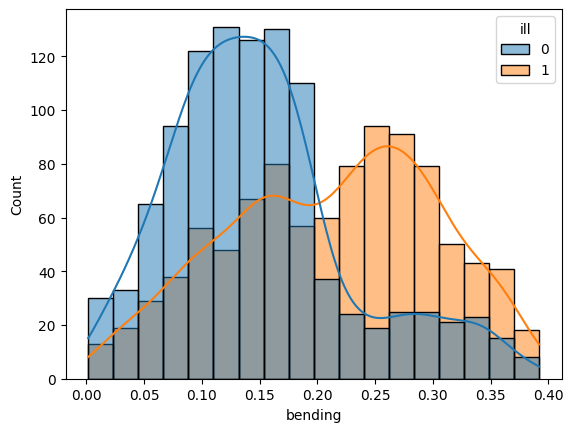

In [42]:
sns.histplot(data=df, x='bending', hue='ill', kde=True)

<Axes: xlabel='main_spherical', ylabel='Count'>

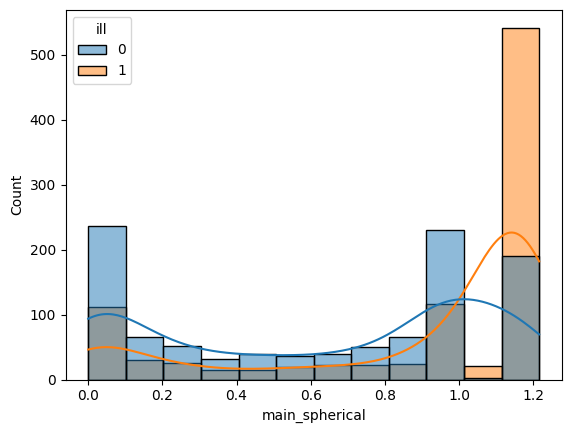

In [43]:
sns.histplot(data=df, x='main_spherical', hue='ill', kde=True)

<Axes: xlabel='sec_spherical', ylabel='Count'>

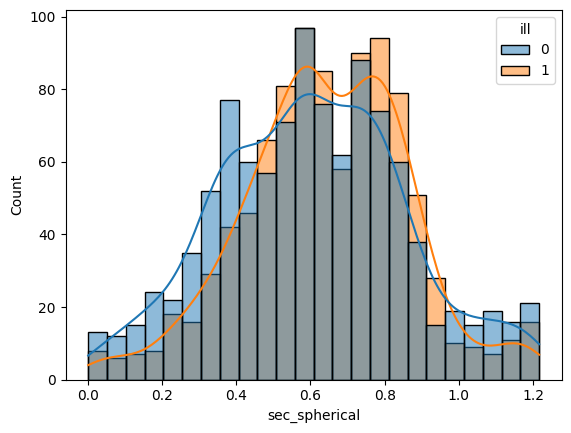

In [44]:
sns.histplot(data=df, x='sec_spherical', hue='ill', kde=True)

<Axes: xlabel='sphere_diff', ylabel='Count'>

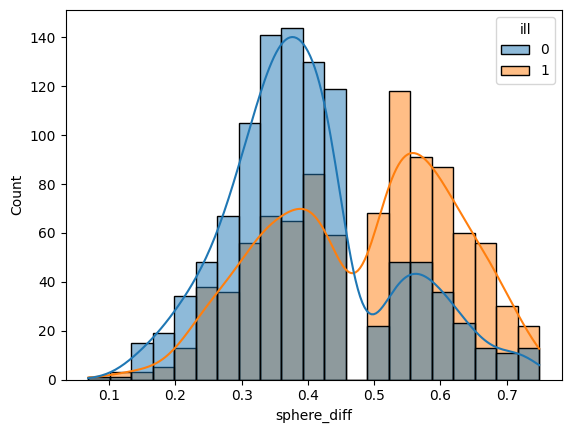

In [45]:
sns.histplot(data=df, x='sphere_diff', hue='ill', kde=True)

<Axes: xlabel='arm_position', ylabel='Density'>

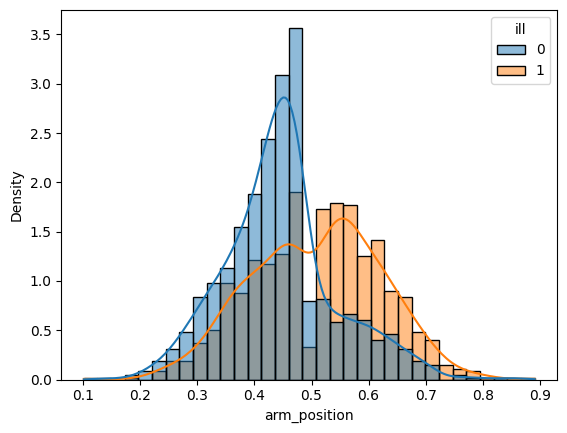

In [46]:
sns.histplot(data=df, x='arm_position', hue='ill', kde=True, stat='density')

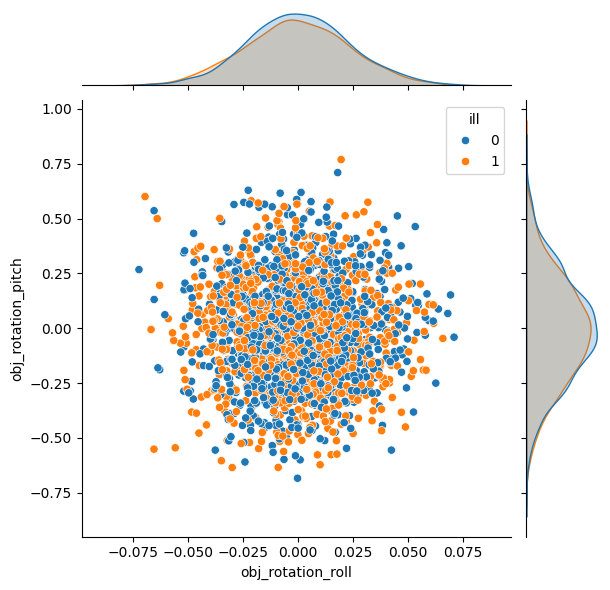

In [47]:
sns.jointplot(data=df, x='obj_rotation_roll', y='obj_rotation_pitch', hue='ill')

In [48]:
def load_imgs(paths):
  imgs = []
  for path in paths:
      img = Image.open(path).convert('RGB')
      imgs.append(img)
  return imgs

In [30]:
notill_samples = df[df.ill == 0].sample(6)
paths = notill_samples.filename.apply(lambda x: data_dir / dataset / x)
notill_imgs = load_imgs(paths)
ill_samples = df[df.ill == 1].sample(6)
paths = ill_samples.filename.apply(lambda x: data_dir / dataset / x)
ill_imgs = load_imgs(paths)

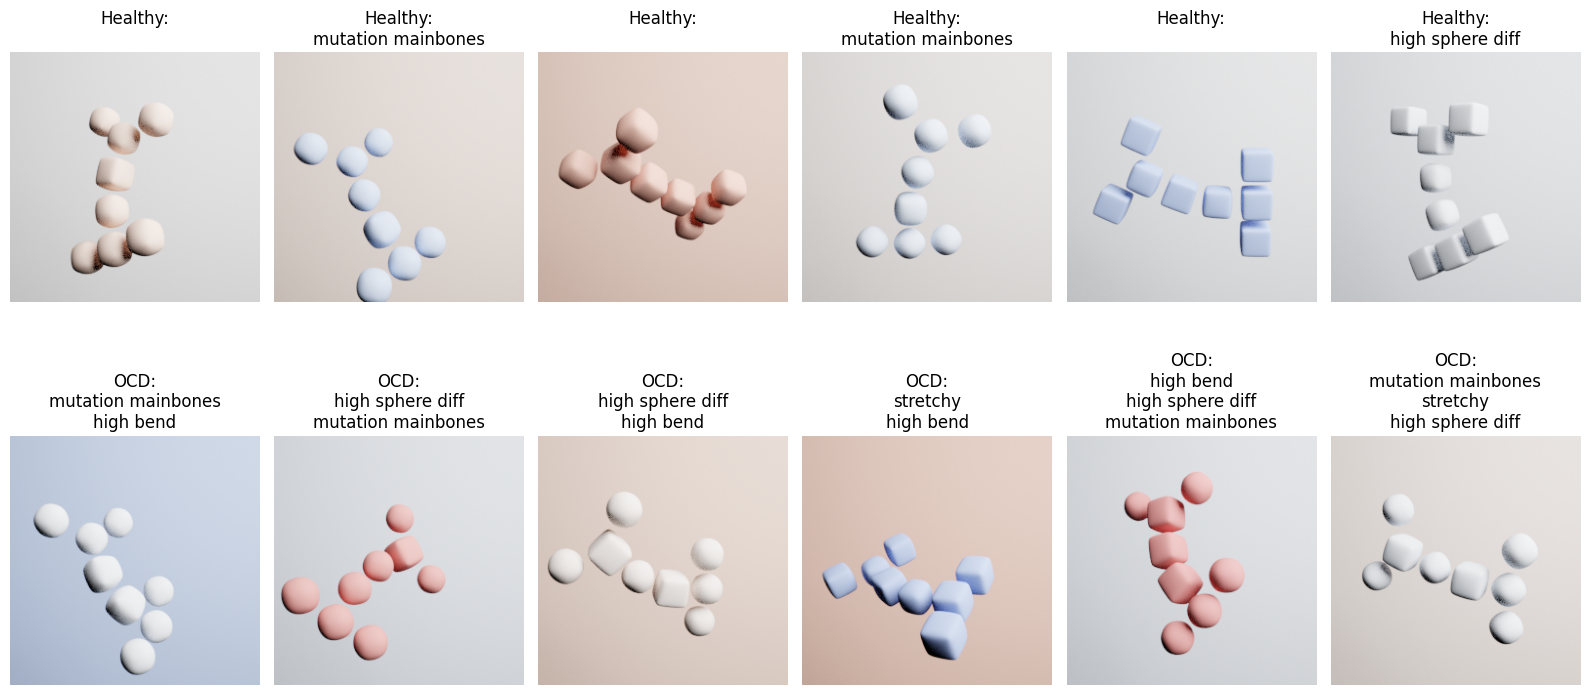

In [31]:
axes = plt.subplots(2, 6, figsize=(16, 8))[1]
for i, img in enumerate(notill_imgs):
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    chars = [c.replace('_', ' ') for c in notill_samples.iloc[i].ill_chars]
    chars = '\n'.join(chars)
    axes[0, i].set_title(f'Healthy:\n{chars}')
for i, img in enumerate(ill_imgs):
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    chars = [c.replace('_', ' ') for c in ill_samples.iloc[i].ill_chars]
    chars = '\n'.join(chars)
    axes[1, i].set_title(f'OCD:\n{chars}')
plt.tight_layout()
plt.show()

In [32]:
ill_samples.iloc[3]

obj_name                                                            ocd
num_ill_chars                                                         2
ill_chars                                         [stretchy, high_bend]
labeling_error                                                    False
main_spherical                                                 0.394546
sec_spherical                                                   0.72516
sec_bones                                                           101
bending                                                        0.207936
obj_rotation_roll                                             -0.768093
obj_rotation_pitch                                            -0.742439
obj_rotation_yaw                                              -0.300355
fliplr                                                            False
position_x                                                    -0.604221
position_y                                                    -0

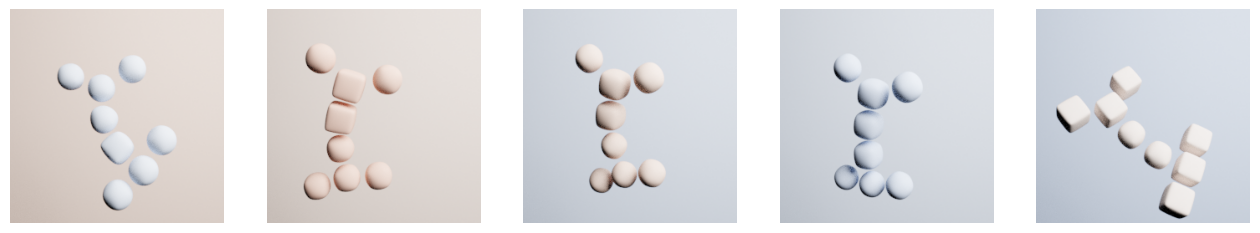

In [33]:
samples = df.sample(5)
paths = samples.filename.apply(lambda x: data_dir / dataset / x)
imgs = load_imgs(paths)

axes = plt.subplots(1, 5, figsize=(16, 4))[1]
for i, img in enumerate(imgs):
    axes[i].imshow(img)
    axes[i].axis('off')

In [34]:
pred = [1, 1, 0, 0, 1]

ill = samples.ill_chars.values
pred = [f'{p} ({i})' for p, i in zip(pred, ill)]
pred

["1 (['high_bend'])",
 "1 (['high_sphere_diff', 'stretchy'])",
 "0 (['stretchy', 'mutation_mainbones'])",
 "0 (['mutation_mainbones'])",
 "1 (['high_sphere_diff'])"]